<div align="center">

# Laboratorio No. 3

## Clasificación de texto con Naive Bayes

<br>

**Curso:** Natural Language Processing  
**Estudiante:** Jose Tánchez  
**Carné:** 20230005  

<br>

---

### Bolsa de Palabras, TF-IDF y Naive Bayes  
### para clasificación de texto

#### Corpus de noticias en español

</div>

# Introducción

En este laboratorio se utilizará el corpus de noticias preparado y normalizado durante el Laboratorio No. 1.

A partir de la columna de texto normalizado se construirán modelos de clasificación utilizando:

1. **Bolsa de Palabras (BoW).**
2. **TF-IDF.**
3. **Naive Bayes Multinomial.**
4. **Una implementación propia de Naive Bayes.**
5. **Variaciones en el tamaño del vocabulario y el uso de n-gramas.**

El corpus se dividirá en conjuntos de entrenamiento, validación y prueba. Los vectorizadores aprenderán su vocabulario únicamente a partir del conjunto de entrenamiento para evitar fuga de información.

Finalmente, se calcularán métricas de clasificación, matrices de confusión y resultados que permitan comparar las diferentes representaciones y modelos.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# Buscar el corpus según la ubicación del notebook actual
rutas_posibles = [
    Path("corpus_normalizado.pkl"),
    Path("../Lab1/corpus_normalizado.pkl"),
    Path("Lab1/corpus_normalizado.pkl")
]

ruta_corpus = next(
    (
        ruta
        for ruta in rutas_posibles
        if ruta.exists()
    ),
    None
)

if ruta_corpus is None:
    raise FileNotFoundError(
        "No se encontró 'corpus_normalizado.pkl'. "
        "Guárdalo primero desde el notebook de Lab 1."
    )

corpus = pd.read_pickle(ruta_corpus)

columnas_requeridas = [
    "url",
    "news",
    "Type",
    "tokens_lematizados",
    "News_normalizada"
]

columnas_faltantes = [
    columna
    for columna in columnas_requeridas
    if columna not in corpus.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan columnas necesarias: {columnas_faltantes}"
    )

print(f"Corpus cargado desde: {ruta_corpus.resolve()}")
print(f"Cantidad de documentos: {len(corpus):,}")
print(f"Cantidad de categorías: {corpus['Type'].nunique()}")
print("El corpus está listo para continuar.")

display(corpus[columnas_requeridas].head())

Corpus cargado desde: /Users/josetanchez/Desktop/NLP-Labs-JoseTanchez/Lab1/corpus_normalizado.pkl
Cantidad de documentos: 1,217
Cantidad de categorías: 7
El corpus está listo para continuar.


,url,news,Type,tokens_lematizados,News_normalizada
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra,"[foro, banca, articulador, empresarial, desarr...",foro banca articulador empresarial desarrollo ...
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones,"[regulador, valor, chino, decir, domingo, busc...",regulador valor chino decir domingo buscar coo...
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas,"[industria, históricamente, masculino, aviació...",industria históricamente masculino aviación vi...
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia,"[dato, marzo, ipc, interanual, encadenar, deci...",dato marzo ipc interanual encadenar decimoquin...
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra,"[ayer, cartagena, dar, inicio, versión, número...",ayer cartagena dar inicio versión número 56 co...


# 1. Conjuntos de entrenamiento, validación y prueba

El corpus se dividirá en tres conjuntos:

- **Entrenamiento:** 70 % de los documentos.
- **Validación:** 15 % de los documentos.
- **Prueba:** 15 % de los documentos.

La separación se realizará con `train_test_split`, utilizando estratificación sobre la columna `Type` para conservar la distribución de las categorías y un estado aleatorio fijo para que el resultado sea reproducible.

El conjunto de entrenamiento se utilizará para ajustar los vectorizadores y los modelos. Los conjuntos de validación y prueba permanecerán separados durante este proceso para evitar fuga de información.

In [7]:
from sklearn.model_selection import train_test_split

semilla_aleatoria = 42

# Agrupar documentos con el mismo texto normalizado
clave_texto = (
    corpus["News_normalizada"]
    .fillna("")
    .str.strip()
)

tabla_grupos_texto = (
    corpus
    .assign(_clave_texto=clave_texto)
    .groupby("_clave_texto", sort=False)
    .agg(
        Categoria_estratificacion=(
            "Type",
            lambda categorias: categorias.mode().iloc[0]
        ),
        Cantidad_documentos=("Type", "size")
    )
    .reset_index()
)

# Separar los grupos en entrenamiento y conjunto temporal
grupos_entrenamiento, grupos_temporales = train_test_split(
    tabla_grupos_texto,
    test_size=0.30,
    random_state=semilla_aleatoria,
    stratify=tabla_grupos_texto[
        "Categoria_estratificacion"
    ]
)

# Dividir los grupos temporales entre validación y prueba
grupos_validacion, grupos_prueba = train_test_split(
    grupos_temporales,
    test_size=0.50,
    random_state=semilla_aleatoria,
    stratify=grupos_temporales[
        "Categoria_estratificacion"
    ]
)

claves_entrenamiento = set(
    grupos_entrenamiento["_clave_texto"]
)
claves_validacion = set(
    grupos_validacion["_clave_texto"]
)
claves_prueba = set(
    grupos_prueba["_clave_texto"]
)

corpus_entrenamiento = corpus.loc[
    clave_texto.isin(claves_entrenamiento)
].copy()

corpus_validacion = corpus.loc[
    clave_texto.isin(claves_validacion)
].copy()

corpus_prueba = corpus.loc[
    clave_texto.isin(claves_prueba)
].copy()

# Verificar que todos los documentos estén presentes una sola vez
assert (
    len(corpus_entrenamiento)
    + len(corpus_validacion)
    + len(corpus_prueba)
    == len(corpus)
)

intersecciones_texto = {
    "Entrenamiento - Validación": len(
        claves_entrenamiento & claves_validacion
    ),
    "Entrenamiento - Prueba": len(
        claves_entrenamiento & claves_prueba
    ),
    "Validación - Prueba": len(
        claves_validacion & claves_prueba
    )
}

assert all(
    cantidad == 0
    for cantidad in intersecciones_texto.values()
)

resumen_particiones = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación",
        "Prueba"
    ],
    "Cantidad de documentos": [
        len(corpus_entrenamiento),
        len(corpus_validacion),
        len(corpus_prueba)
    ]
})

resumen_particiones["Porcentaje del corpus"] = (
    resumen_particiones["Cantidad de documentos"]
    / len(corpus)
    * 100
).round(2)

display(resumen_particiones)

print("Textos normalizados compartidos entre conjuntos:")
for comparacion, cantidad in intersecciones_texto.items():
    print(f"{comparacion}: {cantidad}")

,Conjunto,Cantidad de documentos,Porcentaje del corpus
0,Entrenamiento,850,69.84
1,Validación,185,15.20
2,Prueba,182,14.95


Textos normalizados compartidos entre conjuntos:
Entrenamiento - Validación: 0
Entrenamiento - Prueba: 0
Validación - Prueba: 0


## 1.1 Tamaño de los conjuntos

La división estratificada produjo los siguientes conjuntos:

| Conjunto | Cantidad de documentos | Porcentaje del corpus |
|---|---:|---:|
| Entrenamiento | 850 | 69.84 % |
| Validación | 185 | 15.20 % |
| Prueba | 182 | 14.95 % |

Los documentos con el mismo texto normalizado se mantuvieron dentro de un único conjunto. Por esta razón, las proporciones presentan una pequeña diferencia respecto al 70 %, 15 % y 15 % solicitado.

La verificación confirmó que no existen textos normalizados compartidos entre entrenamiento, validación y prueba. Los tres conjuntos conservan en total los **1,217 documentos** del corpus.

In [8]:
# Conservar un orden único de categorías para todo el laboratorio
orden_categorias = (
    corpus["Type"]
    .value_counts()
    .index
    .tolist()
)

distribucion_categorias_conjuntos = pd.DataFrame({
    "Corpus completo": (
        corpus["Type"]
        .value_counts()
        .reindex(orden_categorias)
    ),
    "Entrenamiento": (
        corpus_entrenamiento["Type"]
        .value_counts()
        .reindex(orden_categorias)
    ),
    "Validación": (
        corpus_validacion["Type"]
        .value_counts()
        .reindex(orden_categorias)
    ),
    "Prueba": (
        corpus_prueba["Type"]
        .value_counts()
        .reindex(orden_categorias)
    )
})

distribucion_categorias_conjuntos.index.name = "Categoría"

porcentajes_categorias_conjuntos = (
    distribucion_categorias_conjuntos
    .div(
        distribucion_categorias_conjuntos.sum(axis=0),
        axis=1
    )
    .mul(100)
    .round(2)
)

print("Cantidad de documentos por categoría:")
display(distribucion_categorias_conjuntos)

print("Porcentaje de documentos por categoría:")
display(
    porcentajes_categorias_conjuntos.style.format(
        "{:.2f}%"
    )
)

Cantidad de documentos por categoría:


,Corpus completo,Entrenamiento,Validación,Prueba
Categoría,,,,
Macroeconomia,340,239,51,50
Alianzas,247,173,37,37
Innovacion,195,138,28,29
Regulaciones,142,99,22,21
Sostenibilidad,137,93,23,21
Otra,130,90,20,20
Reputacion,26,18,4,4


Porcentaje de documentos por categoría:


,Corpus completo,Entrenamiento,Validación,Prueba
Categoría,,,,
Macroeconomia,27.94%,28.12%,27.57%,27.47%
Alianzas,20.30%,20.35%,20.00%,20.33%
Innovacion,16.02%,16.24%,15.14%,15.93%
Regulaciones,11.67%,11.65%,11.89%,11.54%
Sostenibilidad,11.26%,10.94%,12.43%,11.54%
Otra,10.68%,10.59%,10.81%,10.99%
Reputacion,2.14%,2.12%,2.16%,2.20%


## 1.2 Distribución de las categorías

La distribución de documentos por categoría en cada conjunto fue la siguiente:

| Categoría | Corpus completo | Entrenamiento | Validación | Prueba |
|---|---:|---:|---:|---:|
| Macroeconomia | 340 | 239 | 51 | 50 |
| Alianzas | 247 | 173 | 37 | 37 |
| Innovacion | 195 | 138 | 28 | 29 |
| Regulaciones | 142 | 99 | 22 | 21 |
| Sostenibilidad | 137 | 93 | 23 | 21 |
| Otra | 130 | 90 | 20 | 20 |
| Reputacion | 26 | 18 | 4 | 4 |

Las siete categorías del corpus están representadas en los conjuntos de entrenamiento, validación y prueba. El orden definido en esta tabla se conservará posteriormente para mostrar las métricas y las matrices de confusión.

# 2. Bolsa de Palabras (Bag of Words)

En esta sección se construirá el modelo base utilizando una representación de **Bolsa de Palabras**, conocida como **Bag of Words (BoW)**.

El vocabulario se aprenderá exclusivamente a partir del texto normalizado del conjunto de entrenamiento mediante `CountVectorizer`. Posteriormente, el mismo vectorizador se utilizará para transformar los conjuntos de validación y prueba sin modificar el vocabulario aprendido.

Cada documento será representado mediante los conteos de sus palabras y las matrices resultantes se utilizarán para entrenar y evaluar un clasificador `MultinomialNB`.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

textos_entrenamiento = (
    corpus_entrenamiento["News_normalizada"]
    .fillna("")
)

textos_validacion = (
    corpus_validacion["News_normalizada"]
    .fillna("")
)

textos_prueba = (
    corpus_prueba["News_normalizada"]
    .fillna("")
)

# Crear el vectorizador con la misma configuración del Lab 2
vectorizador_bow = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False
)

# Aprender el vocabulario únicamente con entrenamiento
matriz_bow_entrenamiento = (
    vectorizador_bow.fit_transform(
        textos_entrenamiento
    )
)

# Transformar validación y prueba sin modificar el vocabulario
matriz_bow_validacion = vectorizador_bow.transform(
    textos_validacion
)

matriz_bow_prueba = vectorizador_bow.transform(
    textos_prueba
)

vocabulario_bow = (
    vectorizador_bow.get_feature_names_out()
)

resumen_matrices_bow = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación",
        "Prueba"
    ],
    "Forma de la matriz": [
        str(matriz_bow_entrenamiento.shape),
        str(matriz_bow_validacion.shape),
        str(matriz_bow_prueba.shape)
    ],
    "Valores distintos de cero": [
        matriz_bow_entrenamiento.nnz,
        matriz_bow_validacion.nnz,
        matriz_bow_prueba.nnz
    ]
})

display(resumen_matrices_bow)

print(
    f"Vocabulario aprendido con entrenamiento: "
    f"{len(vocabulario_bow):,} términos."
)

,Conjunto,Forma de la matriz,Valores distintos de cero
0,Entrenamiento,"(850, 17922)",158555
1,Validación,"(185, 17922)",33381
2,Prueba,"(182, 17922)",33475


Vocabulario aprendido con entrenamiento: 17,922 términos.


## 2.1 Dimensiones de las matrices BoW

El vectorizador aprendió un vocabulario de **17,922 términos** utilizando únicamente el conjunto de entrenamiento.

Las matrices obtenidas tienen las siguientes dimensiones:

| Conjunto | Forma de la matriz | Valores distintos de cero |
|---|---:|---:|
| Entrenamiento | (850, 17,922) | 158,555 |
| Validación | (185, 17,922) | 33,381 |
| Prueba | (182, 17,922) | 33,475 |

Las tres matrices contienen las mismas **17,922 columnas** porque validación y prueba fueron transformadas con el vocabulario aprendido durante el ajuste del conjunto de entrenamiento.

In [10]:
from sklearn.naive_bayes import MultinomialNB

etiquetas_entrenamiento = (
    corpus_entrenamiento["Type"]
)

etiquetas_validacion = (
    corpus_validacion["Type"]
)

etiquetas_prueba = (
    corpus_prueba["Type"]
)

# Entrenar el modelo base con la representación BoW
modelo_bow = MultinomialNB(
    alpha=1.0
)

modelo_bow.fit(
    matriz_bow_entrenamiento,
    etiquetas_entrenamiento
)

print("Modelo MultinomialNB con BoW entrenado correctamente.")
print(f"Parámetro de suavizado alpha: {modelo_bow.alpha}")
print(f"Cantidad de categorías aprendidas: {len(modelo_bow.classes_)}")
print("Categorías aprendidas:")
print(modelo_bow.classes_)

Modelo MultinomialNB con BoW entrenado correctamente.
Parámetro de suavizado alpha: 1.0
Cantidad de categorías aprendidas: 7
Categorías aprendidas:
['Alianzas' 'Innovacion' 'Macroeconomia' 'Otra' 'Regulaciones'
 'Reputacion' 'Sostenibilidad']


## 2.2 Evaluación del modelo BoW

El modelo BoW se evaluará inicialmente sobre los conjuntos de entrenamiento y validación.

Para cada conjunto se calcularán `accuracy`, precisión, recall y F1-score utilizando promedios macro y ponderado. También se generará el `classification_report` con los resultados de cada categoría.

El conjunto de prueba se mantendrá reservado hasta completar la comparación de las representaciones y modelos.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def calcular_metricas_clasificacion(
    etiquetas_reales,
    predicciones
):
    """
    Calcula las métricas generales de clasificación.
    """

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            etiquetas_reales,
            predicciones,
            average="macro",
            zero_division=0
        )
    )

    precision_ponderada, recall_ponderado, f1_ponderado, _ = (
        precision_recall_fscore_support(
            etiquetas_reales,
            predicciones,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "Accuracy": accuracy_score(
            etiquetas_reales,
            predicciones
        ),
        "Precisión macro": precision_macro,
        "Recall macro": recall_macro,
        "F1 macro": f1_macro,
        "Precisión ponderada": precision_ponderada,
        "Recall ponderado": recall_ponderado,
        "F1 ponderado": f1_ponderado
    }


predicciones_bow_entrenamiento = modelo_bow.predict(
    matriz_bow_entrenamiento
)

predicciones_bow_validacion = modelo_bow.predict(
    matriz_bow_validacion
)

resultados_bow = pd.DataFrame([
    {
        "Modelo": "BoW completo",
        "Conjunto": "Entrenamiento",
        **calcular_metricas_clasificacion(
            etiquetas_entrenamiento,
            predicciones_bow_entrenamiento
        )
    },
    {
        "Modelo": "BoW completo",
        "Conjunto": "Validación",
        **calcular_metricas_clasificacion(
            etiquetas_validacion,
            predicciones_bow_validacion
        )
    }
])

display(
    resultados_bow.round(4)
)

,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,BoW completo,Entrenamiento,0.9435,0.9559,0.9291,0.9398,0.9485,0.9435,0.9438
1,BoW completo,Validación,0.7946,0.8350,0.7089,0.7259,0.8145,0.7946,0.7854


In [12]:
from sklearn.metrics import classification_report

print("REPORTE DE CLASIFICACIÓN — ENTRENAMIENTO\n")

print(
    classification_report(
        etiquetas_entrenamiento,
        predicciones_bow_entrenamiento,
        labels=orden_categorias,
        digits=4,
        zero_division=0
    )
)

print("REPORTE DE CLASIFICACIÓN — VALIDACIÓN\n")

print(
    classification_report(
        etiquetas_validacion,
        predicciones_bow_validacion,
        labels=orden_categorias,
        digits=4,
        zero_division=0
    )
)

REPORTE DE CLASIFICACIÓN — ENTRENAMIENTO

                precision    recall  f1-score   support

 Macroeconomia     0.9502    0.9582    0.9542       239
      Alianzas     0.9939    0.9480    0.9704       173
    Innovacion     0.8364    1.0000    0.9109       138
  Regulaciones     1.0000    0.9293    0.9634        99
Sostenibilidad     0.9368    0.9570    0.9468        93
          Otra     0.9737    0.8222    0.8916        90
    Reputacion     1.0000    0.8889    0.9412        18

      accuracy                         0.9435       850
     macro avg     0.9559    0.9291    0.9398       850
  weighted avg     0.9485    0.9435    0.9438       850

REPORTE DE CLASIFICACIÓN — VALIDACIÓN

                precision    recall  f1-score   support

 Macroeconomia     0.8421    0.9412    0.8889        51
      Alianzas     0.8519    0.6216    0.7188        37
    Innovacion     0.6512    1.0000    0.7887        28
  Regulaciones     0.7368    0.6364    0.6829        22
Sostenibilidad     

## 2.3 Matriz de confusión del modelo BoW

Se construirá la matriz de confusión correspondiente al conjunto de validación para observar la cantidad de predicciones correctas e incorrectas en cada categoría.

Las filas representarán las categorías reales y las columnas representarán las categorías predichas. En ambos ejes se utilizará el orden de categorías definido durante la preparación de los conjuntos.

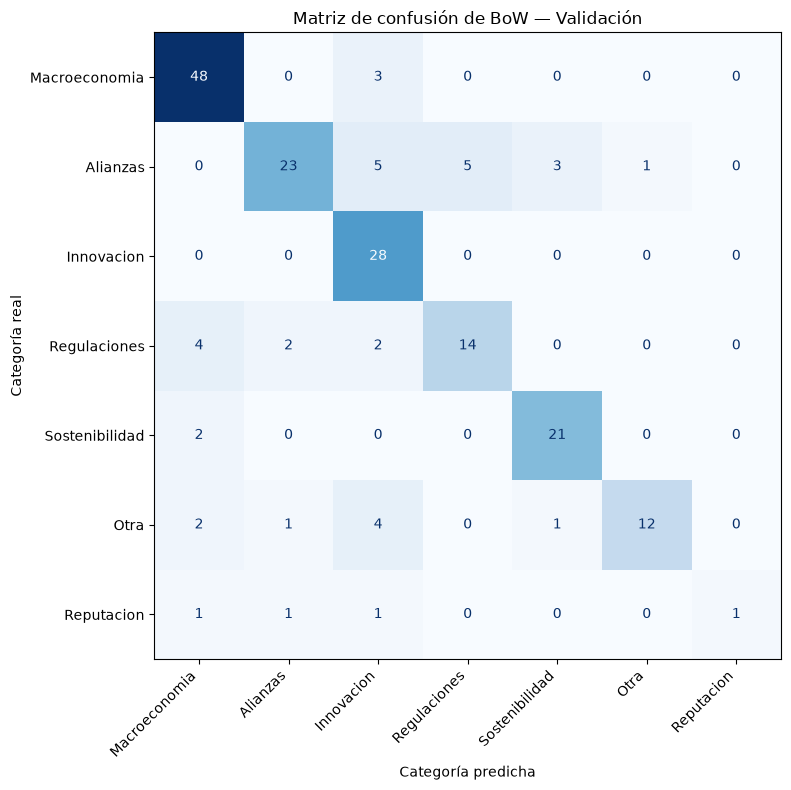

In [13]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

matriz_confusion_bow_validacion = confusion_matrix(
    etiquetas_validacion,
    predicciones_bow_validacion,
    labels=orden_categorias
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

visualizacion_bow = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_bow_validacion,
    display_labels=orden_categorias
)

visualizacion_bow.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de confusión de BoW — Validación"
)
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")
plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## 2.4 Resultados generales del modelo BoW

Las métricas generales obtenidas con la representación BoW fueron:

| Métrica | Entrenamiento | Validación |
|---|---:|---:|
| Accuracy | 0.9435 | 0.7946 |
| Precisión macro | 0.9559 | 0.8350 |
| Recall macro | 0.9291 | 0.7089 |
| F1 macro | 0.9398 | 0.7259 |
| Precisión ponderada | 0.9485 | 0.8145 |
| Recall ponderado | 0.9435 | 0.7946 |
| F1 ponderado | 0.9438 | 0.7854 |

El `classification_report` y la matriz de confusión conservan el detalle de los resultados por categoría. La evaluación sobre el conjunto de prueba permanece pendiente hasta completar la comparación de modelos.

# 3. TF-IDF

En esta sección se construirá una segunda representación utilizando **TF-IDF**.

El vectorizador aprenderá el vocabulario y los pesos IDF exclusivamente a partir del conjunto de entrenamiento. Posteriormente, se utilizará el mismo objeto para transformar los conjuntos de validación y prueba sin realizar un nuevo ajuste.

Las matrices TF-IDF se utilizarán para entrenar otro clasificador `MultinomialNB`, manteniendo separados los objetos correspondientes a BoW y TF-IDF.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador_tfidf = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False
)

# Aprender el vocabulario y los pesos IDF solo con entrenamiento
matriz_tfidf_entrenamiento = (
    vectorizador_tfidf.fit_transform(
        textos_entrenamiento
    )
)

# Transformar validación y prueba sin reajustar el vectorizador
matriz_tfidf_validacion = vectorizador_tfidf.transform(
    textos_validacion
)

matriz_tfidf_prueba = vectorizador_tfidf.transform(
    textos_prueba
)

vocabulario_tfidf = (
    vectorizador_tfidf.get_feature_names_out()
)

resumen_matrices_tfidf = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación",
        "Prueba"
    ],
    "Forma de la matriz": [
        str(matriz_tfidf_entrenamiento.shape),
        str(matriz_tfidf_validacion.shape),
        str(matriz_tfidf_prueba.shape)
    ],
    "Valores distintos de cero": [
        matriz_tfidf_entrenamiento.nnz,
        matriz_tfidf_validacion.nnz,
        matriz_tfidf_prueba.nnz
    ]
})

display(resumen_matrices_tfidf)

print(
    f"Vocabulario aprendido con entrenamiento: "
    f"{len(vocabulario_tfidf):,} términos."
)

,Conjunto,Forma de la matriz,Valores distintos de cero
0,Entrenamiento,"(850, 17922)",158555
1,Validación,"(185, 17922)",33381
2,Prueba,"(182, 17922)",33475


Vocabulario aprendido con entrenamiento: 17,922 términos.


## 3.1 Dimensiones de las matrices TF-IDF

El vectorizador TF-IDF aprendió un vocabulario de **17,922 términos** utilizando únicamente el conjunto de entrenamiento.

Las matrices obtenidas tienen las siguientes dimensiones:

| Conjunto | Forma de la matriz | Valores distintos de cero |
|---|---:|---:|
| Entrenamiento | (850, 17,922) | 158,555 |
| Validación | (185, 17,922) | 33,381 |
| Prueba | (182, 17,922) | 33,475 |

Las dimensiones y la cantidad de valores distintos de cero coinciden con las matrices BoW porque ambas representaciones utilizan el mismo vocabulario de unigramas. La diferencia se encuentra en los valores almacenados: BoW utiliza conteos y TF-IDF utiliza pesos.

In [15]:
# Entrenar MultinomialNB con la representación TF-IDF
modelo_tfidf = MultinomialNB(
    alpha=1.0
)

modelo_tfidf.fit(
    matriz_tfidf_entrenamiento,
    etiquetas_entrenamiento
)

print("Modelo MultinomialNB con TF-IDF entrenado correctamente.")
print(f"Parámetro de suavizado alpha: {modelo_tfidf.alpha}")
print(f"Cantidad de categorías aprendidas: {len(modelo_tfidf.classes_)}")
print("Categorías aprendidas:")
print(modelo_tfidf.classes_)

Modelo MultinomialNB con TF-IDF entrenado correctamente.
Parámetro de suavizado alpha: 1.0
Cantidad de categorías aprendidas: 7
Categorías aprendidas:
['Alianzas' 'Innovacion' 'Macroeconomia' 'Otra' 'Regulaciones'
 'Reputacion' 'Sostenibilidad']
